# 进阶实践项目 02 参考答案：条件 VAE、患者留出与记忆初筛

本答案选择条件 VAE，因为训练相对稳定、潜在空间容易展示，适合课程算力。它不能代表当前最高质量的胸片生成方法。条件 GAN、小型扩散模型、文本条件模型和预训练模型微调都是其他路线。


> **实践定位**
>
> 这不是短时间代码竞赛，也不是以最高分数决定完成度的作业。可以只完成数据核对、基线、一个消融实验或一段严谨的失败分析。问题定义、文献依据、方法选择、验证设计、错误解释和下一步实验，重要性高于单一性能数值。
>
> 最终提交由两部分组成：当前 Notebook，以及一份设计报告。设计报告不是代码说明书，而是研究方案说明。参考答案只展示一种能够运行的方案，不代表唯一正确答案，也不意味着其中的模型一定最适合你的目标。

**参考答案不是唯一正确答案。** 其他方案只要问题定义、数据处理、验证和解释合理，同样可以成立。

## 对应题目 1：环境与输出

32×32 分辨率用于验证生成机制，不用于诊断级结论。固定随机种子后仍需保留多次运行结果，因为生成模型具有明显训练波动。


In [1]:
from pathlib import Path
import json,random,re
import numpy as np,matplotlib.pyplot as plt
from PIL import Image
import torch,torch.nn as nn,torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
SEED=42;random.seed(SEED);np.random.seed(SEED);torch.manual_seed(SEED)
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu');QUICK_MODE=True
OUT=Path('/kaggle/working') if Path('/kaggle').exists() else Path('outputs_adv02');OUT.mkdir(exist_ok=True)


## 对应题目 2：数据发现、患者 ID 与演示回退

文件名中的 `personN` 用作患者分组。若数据文件名不含该模式，应先检查数据说明，而不是把每张图当成独立患者。没有真实数据时使用人工胸廓示意，输出标记为 `demo`。


In [2]:
def find_images():
    rec=[]
    for root in [Path('/kaggle/input'),Path('/mnt/data')]:
      if not root.exists(): continue
      for lab,name in enumerate(['NORMAL','PNEUMONIA']):
        for p in root.glob(f'**/{name}/*'):
          if p.suffix.lower() in {'.jpg','.jpeg','.png'}:
            m=re.search(r'(person\d+)',p.stem.lower()); rec.append((p,lab,m.group(1) if m else p.stem))
    return rec

def demo_records(n=500): return [(None,i%2,f'demo_{i:04d}') for i in range(n)]
recs=find_images();mode='real' if recs else 'demo';recs=recs if recs else demo_records()
groups=np.array([r[2] for r in recs]);idx=np.arange(len(recs))
sp=GroupShuffleSplit(1,test_size=.2,random_state=SEED);tr_idx,ho_idx=next(sp.split(idx,groups=groups))
if QUICK_MODE: tr_idx=tr_idx[:min(1200,len(tr_idx))];ho_idx=ho_idx[:min(200,len(ho_idx))]
print(mode,'train',len(tr_idx),'holdout',len(ho_idx),'patients',len(set(groups)))


demo train 400 holdout 100 patients 500


## 对应题目 3：Dataset 与真实/合成图像表示

图像统一为灰度 32×32 和 `[0,1]`。演示数据只含胸廓与局部斑块，不应被解读为真实肺炎。训练和留出数据使用相同预处理。


In [3]:
class DS(Dataset):
    def __init__(self,ids):self.ids=list(ids)
    def __len__(self):return len(self.ids)
    def __getitem__(self,j):
      i=self.ids[j];p,y,_=recs[i]
      if p is not None:a=np.array(Image.open(p).convert('L').resize((32,32)),np.float32)/255
      else:
       r=np.random.default_rng(i);yy,xx=np.mgrid[:32,:32];a=np.zeros((32,32),np.float32)+.15
       chest=((xx-16)/13)**2+((yy-16)/15)**2<1;a[chest]=.65;a[((xx-10)/6)**2+((yy-16)/11)**2<1]=.25;a[((xx-22)/6)**2+((yy-16)/11)**2<1]=.25
       if y:a[((xx-21)/4)**2+((yy-19)/4)**2<1]+=.35
       a=np.clip(a+r.normal(0,.03,a.shape),0,1).astype(np.float32)
      return torch.tensor(a[None]),torch.tensor(y),recs[i][2]
train_ds=DS(tr_idx);hold_ds=DS(ho_idx);loader=DataLoader(train_ds,32,shuffle=True)


## 对应题目 4：条件 VAE

编码器同时读取图像和 one-hot 条件，输出潜变量均值与方差；解码器再次接收条件。重建项保持样本信息，KL 项约束潜空间。KL 权重较小是为了避免小模型过早只输出平均图像。


In [4]:
class CVAE(nn.Module):
 def __init__(self,z=16):
  super().__init__();self.z=z;self.enc=nn.Sequential(nn.Conv2d(3,16,4,2,1),nn.ReLU(),nn.Conv2d(16,32,4,2,1),nn.ReLU());self.mu=nn.Linear(32*8*8,z);self.lv=nn.Linear(32*8*8,z);self.fc=nn.Linear(z+2,32*8*8);self.dec=nn.Sequential(nn.ConvTranspose2d(32,16,4,2,1),nn.ReLU(),nn.ConvTranspose2d(16,1,4,2,1),nn.Sigmoid())
 def forward(self,x,y):
  oh=F.one_hot(y,2).float()[:,:,None,None].expand(-1,-1,32,32);h=self.enc(torch.cat([x,oh],1)).flatten(1);mu,lv=self.mu(h),self.lv(h);z=mu+torch.randn_like(mu)*torch.exp(.5*lv);return self.sample(z,y),mu,lv
 def sample(self,z,y):return self.dec(self.fc(torch.cat([z,F.one_hot(y,2).float()],1)).view(-1,32,8,8))
m=CVAE().to(DEVICE);opt=torch.optim.Adam(m.parameters(),1e-3);hist=[]
for ep in range(10 if QUICK_MODE else 35):
 ls=[]
 for x,y,_ in loader:
  x=x.to(DEVICE);y=y.to(DEVICE);r,mu,lv=m(x,y);recon=F.binary_cross_entropy(r,x,reduction='sum')/len(x);kl=-.5*(1+lv-mu.pow(2)-lv.exp()).sum()/len(x);loss=recon+.02*kl;opt.zero_grad();loss.backward();opt.step();ls.append(loss.item())
 hist.append(float(np.mean(ls)));print(ep,hist[-1])


0 717.4308518629807
1 630.7205434945913


2 568.579359788161
3 549.9678579477163


4 543.5040987454928
5 540.7300133338341


6 539.272465632512
7 538.4779663085938


8 537.9294151893029
9 537.4344998873197


## 对应题目 5：条件样本与潜在插值

同一批随机潜变量分别配合两类标签生成图像。潜在插值只检查模型输出是否随潜变量平滑变化，不能证明变化对应真实疾病进程。


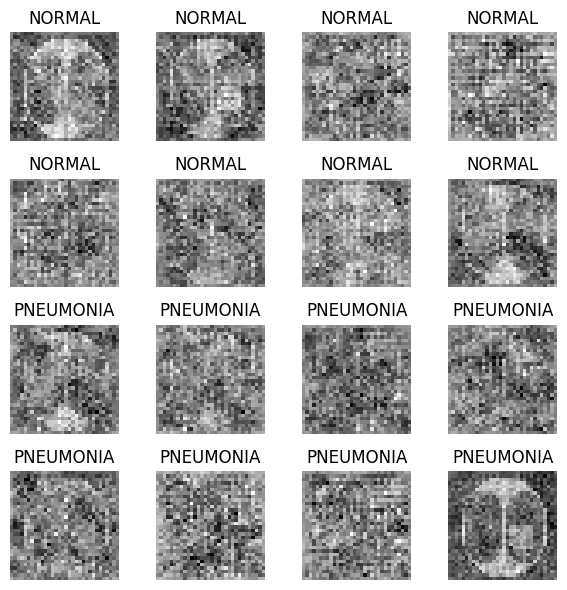

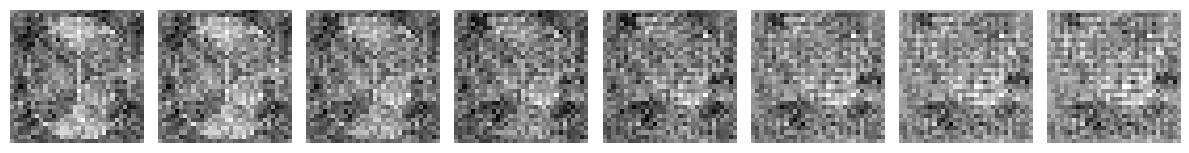

In [5]:
m.eval();z=torch.randn(16,16,device=DEVICE);y=torch.tensor([0]*8+[1]*8,device=DEVICE)
with torch.no_grad():g=m.sample(z,y).cpu().numpy()[:,0]
fig,ax=plt.subplots(4,4,figsize=(6,6))
for a,im,lab in zip(ax.ravel(),g,y.cpu().numpy()):a.imshow(im,cmap='gray');a.set_title('NORMAL' if lab==0 else 'PNEUMONIA');a.axis('off')
plt.tight_layout();plt.savefig(OUT/'adv02_generated.png',dpi=150);plt.show()
z0=torch.randn(1,16,device=DEVICE);z1=torch.randn(1,16,device=DEVICE);zs=torch.cat([(1-t)*z0+t*z1 for t in torch.linspace(0,1,8)],0);ys=torch.ones(8,dtype=torch.long,device=DEVICE)
with torch.no_grad():inter=m.sample(zs,ys).cpu().numpy()[:,0]
fig,ax=plt.subplots(1,8,figsize=(12,2))
for a,im in zip(ax,inter):a.imshow(im,cmap='gray');a.axis('off')
plt.tight_layout();plt.savefig(OUT/'adv02_interpolation.png',dpi=150);plt.show()


## 对应题目 6：多样性、条件一致性与最近邻

像素距离只是一种粗略初筛。参考答案用真实训练图训练简单逻辑回归，先在真实留出集上检查该代理分类器是否有基本区分能力，再观察生成图的条件一致性。最近邻分别在训练集和留出集中计算；这不能完成正式隐私评估，但能发现明显复制。


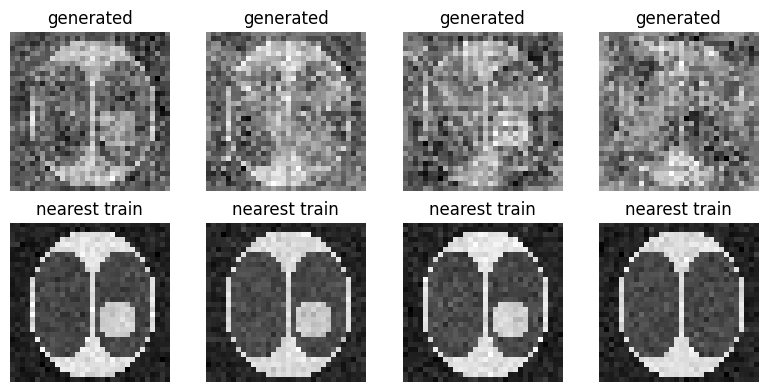

{'mode': 'demo', 'diversity_distance': 2.1601738929748535, 'nearest_train_mse': 0.059545956552028656, 'nearest_holdout_mse': 0.059554170817136765, 'proxy_real_holdout_accuracy': 1.0, 'proxy_generated_condition_accuracy': 0.625}


In [6]:
train_real=np.stack([train_ds[i][0].numpy()[0] for i in range(min(300,len(train_ds)))])
train_lab=np.array([int(train_ds[i][1]) for i in range(min(300,len(train_ds)))])
hold_real=np.stack([hold_ds[i][0].numpy()[0] for i in range(min(120,len(hold_ds)))])
hold_lab=np.array([int(hold_ds[i][1]) for i in range(min(120,len(hold_ds)))])
proxy=LogisticRegression(max_iter=1000).fit(train_real.reshape(len(train_real),-1),train_lab)
proxy_hold=accuracy_score(hold_lab,proxy.predict(hold_real.reshape(len(hold_real),-1)))
proxy_gen=accuracy_score(y.cpu().numpy(),proxy.predict(g.reshape(len(g),-1)))
flat=g.reshape(len(g),-1);div=float(np.mean([np.linalg.norm(flat[i]-flat[j]) for i in range(len(g)) for j in range(i)]))
train_dist=((flat[:,None]-train_real.reshape(len(train_real),-1)[None])**2).mean(2);hold_dist=((flat[:,None]-hold_real.reshape(len(hold_real),-1)[None])**2).mean(2)
nearest_train=float(np.mean(np.min(train_dist,1)));nearest_hold=float(np.mean(np.min(hold_dist,1)))
# 展示每个生成样本的训练最近邻
sel=np.argsort(np.min(train_dist,1))[:4];fig,ax=plt.subplots(2,4,figsize=(8,4))
for j,i in enumerate(sel):
 ax[0,j].imshow(g[i],cmap='gray');ax[0,j].set_title('generated');ax[0,j].axis('off')
 ax[1,j].imshow(train_real[np.argmin(train_dist[i])],cmap='gray');ax[1,j].set_title('nearest train');ax[1,j].axis('off')
plt.tight_layout();plt.savefig(OUT/'adv02_nearest_neighbors.png',dpi=150);plt.show()
metrics={'mode':mode,'diversity_distance':div,'nearest_train_mse':nearest_train,'nearest_holdout_mse':nearest_hold,'proxy_real_holdout_accuracy':float(proxy_hold),'proxy_generated_condition_accuracy':float(proxy_gen)}
print(metrics);json.dump(metrics,open(OUT/'adv02_result.json','w'),indent=2)


## 如何对应题目阅读本答案

- 数据来源、患者分组与留出：第 2–3 部分；
- 模型选择：第 4 部分；
- 条件与潜在空间：第 5 部分；
- 多样性、条件一致性和记忆风险：第 6 部分。

该答案没有证明合成胸片可用于诊断或隐私安全。其他方案可选择 cGAN、扩散模型、报告条件或下游数据增强，但必须保留真实患者独立测试。

完整的示范研究说明见同目录 `项目02_参考设计报告.md`。其中包括研究问题、数据独立性、文献依据、方法选择、评价、结果解释、局限、下一步实验和本包运行记录。它仍然只是一种参考方案。